# Autonomous Incident Response System for AWS
---

In this example, we will build an Agentic system to respond to incidents in your AWS accounts. This is a multi-agent system that composes 4 main components: 

1. **Monitoring**: This composes of a couple of aspects which includes monitoring CloudWatch alarms on the pre-built alarms that have already been set in your account. This might include high `CPU` usage, unhealthy load balancers, SageMaker instance cost allocations, etc. This would also include observing logs from different services from your account and classifying those logs into `Critical` (for example service down, `CPU`>`90%`), `Warning` (for example, latency > threshold, or if something goes beyond a threshold for a specific service) and `Informational` (for example, routine backups, information on various running applications in the AWS account, etc.).

1. **Diagnosis**: This includes diagnosis events that are seen through the monitoring agent. This can include querying `AWS` CloudTrail for additional data, X-Ray data and document these findings in reports that can be saved and used later in the resolution process. This would contain information only on the errors and the different services that need a resolution.

1. **Resolution**: This portion of the solution will be triggered by a diagnosis done from the step before. Once the diagnoses is done with the clear report, then this portion starts to remediate certain actions, such as adjusting EC2 auto-scaling group capacities, invoking functions to rollback deployments, etc. This agent is an essential part of the system since it will be using AWS `API`s in real time to manage the resources.

1. **Communication**: Last, this agent is responsible for keeping track of updates, creating and updating tickets in Jira, sending real time notifications to Slack with the incident details and resolution updates.

This solution will also contain aspects for observabilitiy and tracing but without further ado, let's get right into it.

In [1]:
# LangGraph is a low level orchestration framework for building controllable agents. 
# While langchain provides integrations and composable components to streamline LLM application development, 
# the LangGraph library enables agent orchestration, long term memory, human in the loop and customizable architectures.

In [2]:
import boto3
import logging
from datetime import datetime, timedelta
from typing import Annotated, List, Dict, Any
from typing_extensions import TypedDict
# import langgraph relevant libraries
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Import the memory saver to save in checkpoint and in some thread to retain agent's memory
from langgraph.checkpoint.memory import MemorySaver

# langchain imports
from langchain_aws.chat_models import ChatBedrockConverse
from langchain_core.tools import tool

In [3]:
from colorama import init, Fore, Style
import logging
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

# Initialize colorama
init()

# Set up a logger for pretty printing
logger = logging.getLogger("aws_monitoring_workflow")
logger.setLevel(logging.INFO)

# Remove any existing handlers to avoid duplicate logs
if logger.hasHandlers():
    for handler in logger.handlers:
        logger.removeHandler(handler)

# Add a new handler with formatting
handler = logging.StreamHandler()
formatter = logging.Formatter('%(message)s')
handler.setFormatter(formatter)
logger.addHandler(handler)

def pretty_print_messages(messages_data):
    """Format and print messages from agents in a readable format."""
    if isinstance(messages_data, dict) and "messages" in messages_data:
        messages = messages_data["messages"]
        for msg in messages:
            if isinstance(msg, HumanMessage):
                logger.info(f"{Fore.GREEN}[HUMAN] {msg.content}{Style.RESET_ALL}")
            elif isinstance(msg, AIMessage):
                logger.info(f"{Fore.BLUE}[AI] {msg.content}{Style.RESET_ALL}")
            elif isinstance(msg, ToolMessage):
                logger.info(f"{Fore.YELLOW}[TOOL] {msg.name}: {msg.content[:100]}...{Style.RESET_ALL}")
            else:
                logger.info(f"[OTHER] {msg}")

In [4]:
# define the constants
AMAZON_NOVA_PRO_MODEL_ID: str = 'us.amazon.nova-pro-v1:0'
META_LLAMA_3_2_11B_VISION_INSTRUCT: str = 'us.meta.llama3-2-11b-instruct-v1:0'

### State definitions
---

First, we will define the state for our sub agents: for Monitoring, Diagnosis, Remediation and the Supervisor. Since all of these will have similar states, let's go ahead and define a common `incidentState`.

In [5]:
from langchain_core.messages import BaseMessage
from typing import Optional

class IncidentState(TypedDict):
    """
    A state in LangGraph is a shared data structure, typically a TypedDict or a Pydantic
    model that represents the current snapshot of your application and allows nodes to communicate and 
    exchange data by reading and writing to it.
    """
    messages: List[BaseMessage]
    alarms: Optional[List[Dict]]
    metrics: Optional[Dict]
    instance_ids: Optional[List[str]]
    diagnosis_report: Optional[str]
    remediation_actions: Optional[List[str]]
    notification_status: Optional[str]


With the help of this unified state, this does as follows:

1. **Ensures consistency**: Each agent in this case works with a consistent structure.

1. **Ease of communication**: This facilitates simpler data passing between nodes.

1. **Traceability**: Incident lifecycle remains centralized.

In [6]:
from langchain_core.messages import HumanMessage

# let's define the LLM that will be used in the monitoring agent
llm = ChatBedrockConverse(
    model_id = AMAZON_NOVA_PRO_MODEL_ID, 
    temperature = 0.1,
)

#### Define monitoring tools
---

In [7]:
import boto3
from datetime import timedelta
from langchain_core.tools import BaseTool, tool
from langgraph.prebuilt import create_react_agent

# define some boto3 and AWS clients
cloudwatch_client = boto3.client('cloudwatch')
cloudtrail_client = boto3.client('cloudtrail')
xray_client = boto3.client('xray')
autoscaling_client = boto3.client('autoscaling')
ec2_client = boto3.client('ec2')
# The AWS Health client (requires appropriate support plan)
health_client = boto3.client('health')


@tool
def fetch_ec2_metrics_for_alarm_instances(
    alarm_state: str = "ALARM",
    period: int = 300
) -> Optional[Dict[str, Dict[str, Optional[float]]]]:
    """
    Fetches alarms and retrieves key utilization metrics for affected EC2 instances.
    Returns a dictionary mapping instance IDs to their metrics summary.
    """
    try:
        alarm_response = cloudwatch_client.describe_alarms(StateValue=alarm_state, MaxRecords=100)
    except Exception as e:
        logger.error(f"Error fetching alarms: {e}")
        return None

    if not alarm_response or not alarm_response.get("MetricAlarms"):
        logger.info(f"No alarms found in state: {alarm_state}")
        return {}

    # Extract instance IDs from the alarms
    alarm_instances = {dim["Value"]
                       for alarm in alarm_response["MetricAlarms"]
                       for dim in alarm.get("Dimensions", [])
                       if dim["Name"] == "InstanceId"}

    # List of metrics to fetch from CloudWatch
    metrics_to_fetch = [
        "CPUUtilization", "NetworkIn", "NetworkOut",
        "DiskReadOps", "DiskWriteOps", "StatusCheckFailed"
    ]
    instance_metrics_summary = {}

    for instance_id in alarm_instances:
        instance_summary = {}
        for metric_name in metrics_to_fetch:
            try:
                response = cloudwatch_client.get_metric_statistics(
                    Namespace="AWS/EC2",
                    MetricName=metric_name,
                    Dimensions=[{'Name': 'InstanceId', 'Value': instance_id}],
                    Period=period,
                    Statistics=['Average'],
                    StartTime=datetime.utcnow() - timedelta(minutes=10),
                    EndTime=datetime.utcnow()
                )
                datapoints = response.get("Datapoints", [])
                if datapoints:
                    # Sort datapoints by timestamp to pick the latest value
                    datapoints.sort(key=lambda x: x['Timestamp'], reverse=True)
                    instance_summary[metric_name] = datapoints[0]["Average"]
                else:
                    instance_summary[metric_name] = None
            except Exception as e:
                logger.error(f"Error fetching metric '{metric_name}' for {instance_id}: {e}")
                instance_summary[metric_name] = None
        instance_metrics_summary[instance_id] = instance_summary

    return instance_metrics_summary

monitoring_toolkit = [fetch_ec2_metrics_for_alarm_instances]

In [8]:
from typing import Dict, List, Literal, TypedDict
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END, StateGraph
from langgraph.types import Command
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [9]:
# create the monitoring agent.
# We will create a Reason and Act agent from langchain that will be able to break down the problem 
# into specific tasks and will be able to determine which tool to call.
monitoring_system_prompt = """
You are the monitoring agent responsible for checking the status of AWS services.
Your tasks include:
1. Check the status of reported AWS services (particularly EC2 instances).
2. Identify any performance issues, outages, or anomalies.
3. Collect relevant metrics like CPU usage, memory utilization, network statistics.
4. Also fetch cloudwatch events which indicate incidents that cannot be automatically remediated and require human intervention.
5. Report your findings to the supervisor.
Use any AWS monitoring tools you have access to (CloudWatch, AWS Health Dashboard, etc.).
Be thorough in your investigation but concise in your reporting.
Mark your work as complete by saying "MONITORING COMPLETE" at the end of your response.
"""
monitoring_agent = create_react_agent(llm, tools=monitoring_toolkit, prompt=monitoring_system_prompt)
logger.info(f"Created the monitoring agent: {monitoring_agent}")

Created the monitoring agent: <langgraph.graph.state.CompiledStateGraph object at 0x10ddcb890>


In [10]:
def monitoring_node(state: Dict) -> Dict:
    """Monitoring agent node to check AWS service status."""
    # Retrieve the current messages from state (defaulting to an empty list if missing)
    messages = state.get("messages", [])
    
    # Invoke the monitoring agent with the current messages
    response = monitoring_agent.invoke({"role": "user", "messages": messages})
    
    # Process the agent's response to extract content and create an AIMessage
    if hasattr(response, "content"):
        content = response.content
        ai_message = response
    elif isinstance(response, str):
        content = response
        ai_message = AIMessage(content=content)
    elif isinstance(response, dict) and "content" in response:
        content = response["content"]
        ai_message = AIMessage(content=content)
    else:
        content = str(response)
        ai_message = AIMessage(content=content)
    
    # Retrieve or initialize the workflow state, and update the monitoring flag
    workflow_state = state.get("workflow_state", {})
    workflow_state["monitoring_complete"] = "MONITORING COMPLETE" in content
    
    # Optionally, update other fields in your state (e.g., diagnosis_report, alarms) based on content
    
    # Return the updated state with the new message appended and the workflow state updated
    return {
        "messages": messages + [ai_message],
        "workflow_state": workflow_state
    }

#### Define diagnosis tools
---

In [11]:
from langchain_core.messages import HumanMessage

# let's define the LLM that will be used in the diagnosis agent. We will be using
# the llama3.2 11b vision instruct model which will be capable of complex reasoning and 
# come up with a diagnosis plan
diagnosis_llm = ChatBedrockConverse(
    model_id = AMAZON_NOVA_PRO_MODEL_ID, 
    temperature = 0.1,
)

In [12]:
import boto3
from typing import List, Dict, Union

@tool
def diagnose_ec2_and_health(instance_ids: Union[str, List[str]], event_status: str = "open") -> Dict:
    """
    Consolidated diagnostic tool for EC2 instances and AWS Health events.
    
    Parameters:
      - instance_ids: Either a single instance ID string or list of EC2 instance IDs to check
      - event_status: Filter for AWS Health events (e.g., "open", "closed"). Default is "open"
      
    Returns a dictionary with:
      - "instance_status": EC2 instance status details
      - "health_events": List of AWS Health events matching the provided status
    """
    results = {}
    
    # Convert string input to list if necessary
    if isinstance(instance_ids, str):
        if ',' in instance_ids:
            instance_ids = [id.strip() for id in instance_ids.split(',')]
        else:
            instance_ids = [instance_ids]
    
    # 1. Fetch EC2 instance status
    try:
        ec2_client = boto3.client('ec2')
        status_response = ec2_client.describe_instance_status(InstanceIds=instance_ids)
        instance_status = {}
        for status in status_response.get('InstanceStatuses', []):
            instance_id = status['InstanceId']
            instance_status[instance_id] = {
                'InstanceStatus': status.get('InstanceStatus', {}).get('Status'),
                'SystemStatus': status.get('SystemStatus', {}).get('Status'),
                'Events': [event.get('Description') for event in status.get('Events', [])]
            }
    except Exception as e:
        instance_status = {"error": f"Error retrieving instance status: {str(e)}"}
    
    results['instance_status'] = instance_status
    return results

diagnosis_toolkit = [diagnose_ec2_and_health]

In [13]:
diagnosis_agent = create_react_agent(
    diagnosis_llm, 
    tools=diagnosis_toolkit, 
    prompt="""You are a specialized AWS diagnosis agent focused on analyzing EC2 instance issues.
    When given information about EC2 instances with alarms or performance issues:
    1. Gather detailed information about the instances
    2. Check instance status and recent events
    3. If you have access to an ec2 instance id, then only use that, do not make up an EC2 instance id
    4. If there are no EC2 instances that are provided, then mention to provide more information on those
    5. Always be accurate and never make anything up.
    6. Create and diagnose the current EC2 instance based on the instance ID that you have access to.
    
    Be thorough in your analysis, but prioritize the most relevant information.
    
    ALWAYS END YOUR RESPONSE WITH THE EXACT PHRASE "DIAGNOSIS COMPLETE" ON A NEW LINE. 
    This is required to signal that you've finished your diagnosis.
    """
)

In [14]:
def diagnosis_node(state: Dict) -> Dict:
    """Diagnosis agent node to analyze root causes."""
    messages = state.get("messages", [])
    workflow = state.get("workflow", {
        "current_step": "diagnosis_agent",
        "monitoring_complete": True,
        "diagnosis_complete": False,
        "resolution_complete": False
    })
    
    # Invoke the diagnosis chain with the current messages
    response = diagnosis_agent.invoke({"messages": messages})
    
    # Extract content from the response
    if isinstance(response, dict) and "messages" in response:
        ai_message = response["messages"][-1]
    elif hasattr(response, "content"):
        ai_message = AIMessage(content=response.content)
    elif isinstance(response, str):
        ai_message = AIMessage(content=response)
    else:
        ai_message = AIMessage(content=str(response))
    
    # Make sure the response ends with the completion marker if not already there
    if not ai_message.content.strip().upper().endswith("DIAGNOSIS COMPLETE"):
        ai_message = AIMessage(content=ai_message.content.strip() + "\n\nDIAGNOSIS COMPLETE")
    
    # Update messages with the AI message
    new_messages = messages + [ai_message]
    
    return {
        "messages": new_messages,
        "workflow": workflow
    }

### Test the monitoring and diagnosis agents
---

Next, after we have defined our monitoring and diagnosis tools and created the agents, we can invoke to test how they work.

In [15]:
from langchain_core.messages import HumanMessage
content = """
I want to check the status of my EC2 instances and cloudwatch metrics in my account.
"""

# Invoke monitoring agent with the given message
monitoring_response = monitoring_agent.invoke({"messages": [HumanMessage(content=content)]})
logger.info(monitoring_response["messages"])


/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_76724/1484446638.py:58: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  StartTime=datetime.utcnow() - timedelta(minutes=10),
/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_76724/1484446638.py:59: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  EndTime=datetime.utcnow()
[HumanMessage(content='\nI want to check the status of my EC2 instances and cloudwatch metrics in my account.\n', additional_kwargs={}, response_metadata={}, id='38807b80-ef77-4b84-9e5f-198b1c72e870'), AIMessage(content=[{'type': 'text', 'text': '<thinking> To check the status of the EC2 instances and CloudWatch metrics, I need to fetch the al

In [16]:
from langchain_core.messages import HumanMessage
content = """
I want to check the status of my EC2 instance: i-05ed78c3e64323343
"""

# Invoke monitoring agent with the given message
diagnosis_response = diagnosis_agent.invoke({"messages": [HumanMessage(content=content)]})
logger.info(diagnosis_response["messages"])

[HumanMessage(content='\nI want to check the status of my EC2 instance: i-05ed78c3e64323343\n', additional_kwargs={}, response_metadata={}, id='5c4654ee-4cdf-497c-ad63-a7c941810a09'), AIMessage(content=[{'type': 'text', 'text': '<thinking> The user has provided an EC2 instance ID. I will use the `diagnose_ec2_and_health` tool to gather detailed information about the instance status and any relevant AWS Health events. </thinking>\n'}, {'type': 'tool_use', 'name': 'diagnose_ec2_and_health', 'input': {'instance_ids': 'i-05ed78c3e64323343'}, 'id': 'tooluse_ftK_JMX3QvWDwl2xnS4Nkg'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '002f9051-ff4d-4d39-9ebf-e76e45d97415', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Wed, 19 Mar 2025 18:02:15 GMT', 'content-type': 'application/json', 'content-length': '529', 'connection': 'keep-alive', 'x-amzn-requestid': '002f9051-ff4d-4d39-9ebf-e76e45d97415'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs

### Create the resolution tools
---

In this portion of the notebook, we will create a sub agent that will come up with a resolution. In this case, we will create a simple ticket on JIRA that the agent will assign to someone to take a look at.

In [17]:
import os
import json
from langchain_community.utilities.jira import JiraAPIWrapper

# Set environment variables
os.environ["JIRA_API_TOKEN"] = "ATATT3xFfGF0J9zOQg3TucMe0cKn6VNQI7eHRpoxyULN0kX7cwQ3kr67k6--8KeUmd2pL0WHqBS93DvzZOUlhGZ1MvJKF7GFg9Jx3Snh4jreXSmT7vEeO5kR6eeVG1NaDY73MhMuJ8tNtackXTt45mPxLG-7IL7MRlnIY40IG3pzwboLyGI-wJU=9D48F2F6"
os.environ["JIRA_USERNAME"] = "madhur.prashant7@gmail.com"
os.environ["JIRA_INSTANCE_URL"] = "https://madhurprashant7.atlassian.net"
os.environ["JIRA_CLOUD"] = "True"
os.environ['PROJECT_KEY'] = "AIRT"

In [18]:
# use a small model to create and assign the issue. 
resolution_llm = ChatBedrockConverse(
    model_id = f"us.amazon.nova-micro-v1:0", 
    temperature = 0.1,
)

In [19]:
autoscaling_client = boto3.client('autoscaling')
ec2_client = boto3.client('ec2')
lambda_client = boto3.client('lambda')
ecs_client = boto3.client('ecs')

In [20]:
from langchain_core.messages import HumanMessage, AIMessage
from typing import Dict
import json
from langchain_community.utilities.jira import JiraAPIWrapper

@tool
def create_jira_issue(summary: str, description: str, project_key: str = 'AIRT', issue_type: str = "Task", assignee: str = None):
    """
    Creates a new issue in Jira with the specified details.
    """
    try:
        print(f"Creating Jira issue with project_key: {project_key}")
        
        jira = JiraAPIWrapper()
        
        # Create the issue fields dictionary
        issue_fields = {
            "summary": summary,
            "description": description,
            "issuetype": {"name": issue_type},
            "project": {"key": project_key},
        }
        if assignee:
            issue_fields["assignee"] = {"name": assignee}
        
        # Convert dictionary to JSON string
        issue_fields_json = json.dumps(issue_fields)
        print(f"Sending JSON: {issue_fields_json}")
        
        # Pass the JSON string to the issue_create method
        result = jira.issue_create(issue_fields_json)
        return result
        
    except Exception as e:
        print(f"Error occurred: {str(e)}")
        return {"error": f"Error creating Jira issue: {str(e)}"}
    
resolution_toolkit = [create_jira_issue]

In [21]:
resolution_agent = create_react_agent(
    resolution_llm,
    tools=resolution_toolkit,
    prompt=f"""You are an agent responsible for creating Jira tickets based on the diagnosis provided.
    When given a diagnosis:
    1. Extract the necessary information to create a Jira ticket.
    2. Use the 'create_jira_issue' tool to create the ticket.
    3. Confirm the creation of the ticket and if the diagnosis or information on 
    the EC2 instance seems critical then explain or express that in the JIRA
    ticket description.
    4. Create an in detail task, project key and how to diagnose it within the JIRA ticket.
    the project key is {os.environ['PROJECT_KEY']}"""
)

In [22]:
# Define the resolution node for the workflow
def resolution_node(state: Dict) -> Dict:
    """Resolution agent node to create JIRA tickets."""
    messages = state["messages"]
    
    # Run the resolution agent
    response = resolution_agent.invoke({"messages": messages})
    
    # Extract content from response based on its structure
    if hasattr(response, "content"):
        content = response.content
    elif isinstance(response, str):
        content = response
    elif isinstance(response, dict) and "content" in response:
        content = response["content"]
    elif hasattr(response, "text"):
        content = response.text
    elif isinstance(response, dict) and "messages" in response:
        # Handle the case where response contains messages
        last_message = response["messages"][-1] if response["messages"] else None
        content = last_message.content if hasattr(last_message, "content") else str(last_message)
    else:
        content = str(response)
    
    # Update workflow state
    workflow_state = state.get("workflow_state", {})
    workflow_state["resolution_complete"] = "RESOLUTION COMPLETE" in content
    
    # Format response as AI message
    ai_message = AIMessage(content=content)
    
    return {
        "messages": messages + [ai_message],
        "workflow_state": workflow_state
    }

In [23]:
content = """
The status of my EC2 instance: i-05ed78c3e64323343 is in alarm state.
"""

# Invoke monitoring agent directly
resolution_response = resolution_agent.invoke({"messages": [HumanMessage(content=content)]})
logger.info(resolution_response["messages"])

Creating Jira issue with project_key: AIRT
Sending JSON: {"summary": "EC2 Instance i-05ed78c3e64323343 in Alarm State", "description": "The EC2 instance with ID i-05ed78c3e64323343 is currently in an alarm state. This indicates a critical issue that needs immediate attention. To diagnose the issue, please check the CloudWatch alarms associated with this instance and investigate the metrics that triggered the alarm. Further, check the system logs and any attached monitoring tools for more insights.", "issuetype": {"name": "Task"}, "project": {"key": "AIRT"}}


[HumanMessage(content='\nThe status of my EC2 instance: i-05ed78c3e64323343 is in alarm state.\n', additional_kwargs={}, response_metadata={}, id='29faf124-a32a-43f9-9b9a-9746d53325a6'), AIMessage(content=[{'type': 'text', 'text': "<thinking> To create a Jira ticket based on the diagnosis provided, I need to extract the necessary information and then use the 'create_jira_issue' tool to create the ticket. The diagnosis indicates that an EC2 instance is in an alarm state, which seems critical. I will include this in the Jira ticket description and provide detailed steps on how to diagnose the issue. The project key for this will be 'AIRT'.</thinking>\n\n"}, {'type': 'tool_use', 'name': 'create_jira_issue', 'input': {'summary': 'EC2 Instance i-05ed78c3e64323343 in Alarm State', 'project_key': 'AIRT', 'description': 'The EC2 instance with ID i-05ed78c3e64323343 is currently in an alarm state. This indicates a critical issue that needs immediate attention. To diagnose the issue, please chec

### Create the supervisor agent and the graph and invoke all agents all together

In [24]:
from typing import Dict, List, Literal, TypedDict
from langgraph.graph import MessagesState, END, StateGraph
from langgraph.types import Command
from langchain_core.messages import HumanMessage, AIMessage

# Define the workflow state
class WorkflowState(TypedDict, total=False):
    current_step: str
    monitoring_complete: bool
    diagnosis_complete: bool
    resolution_complete: bool

# Extended state that includes workflow state
class AWSMonitoringState(MessagesState):
    workflow: WorkflowState

# Supervisor node determines next agent
def supervisor_node(state):
    messages = state.get("messages", [])
    workflow = state.get("workflow", {
        "current_step": "monitoring_agent",
        "monitoring_complete": False,
        "diagnosis_complete": False,
        "resolution_complete": False
    })
    
    # Check last message for completion markers
    if messages and len(messages) >= 1 and isinstance(messages[-1], AIMessage):
        content = messages[-1].content
        if "MONITORING COMPLETE" in content.upper():
            workflow["monitoring_complete"] = True
            workflow["current_step"] = "diagnosis_agent"
        elif "DIAGNOSIS COMPLETE" in content.upper():
            workflow["diagnosis_complete"] = True
            workflow["current_step"] = "resolution_agent"
        elif "RESOLUTION COMPLETE" in content.upper():
            workflow["resolution_complete"] = True
            workflow["current_step"] = "END"
    
    # If resolution is happening and the agent has run at least once, consider it complete
    if workflow["current_step"] == "resolution_agent" and workflow["diagnosis_complete"] and len(messages) >= 5:
        workflow["resolution_complete"] = True
        workflow["current_step"] = "END"
    
    # Determine the next step based on workflow state
    next_step = workflow["current_step"]
    
    print(f"Supervisor routing to: {next_step}")
    print(f"Workflow state: {workflow}")
    
    if next_step == "END":
        return {"next": END, "workflow": workflow}
    return {"next": next_step, "workflow": workflow}

# Create the graph
workflow_graph = StateGraph(AWSMonitoringState)

# Add nodes
workflow_graph.add_node("supervisor", supervisor_node)
workflow_graph.add_node("monitoring_agent", monitoring_node)
workflow_graph.add_node("diagnosis_agent", diagnosis_node)
workflow_graph.add_node("resolution_agent", resolution_node)

# Set the entrypoint
workflow_graph.set_entry_point("supervisor")

# Add conditional edges from supervisor
workflow_graph.add_conditional_edges(
    "supervisor",
    lambda state: state["next"], 
    {
        "monitoring_agent": "monitoring_agent",
        "diagnosis_agent": "diagnosis_agent",
        "resolution_agent": "resolution_agent",
        END: END
    }
)

# Add edges from agents back to supervisor
workflow_graph.add_edge("monitoring_agent", "supervisor")
workflow_graph.add_edge("diagnosis_agent", "supervisor")
workflow_graph.add_edge("resolution_agent", "supervisor")
aws_monitoring_workflow = workflow_graph.compile()

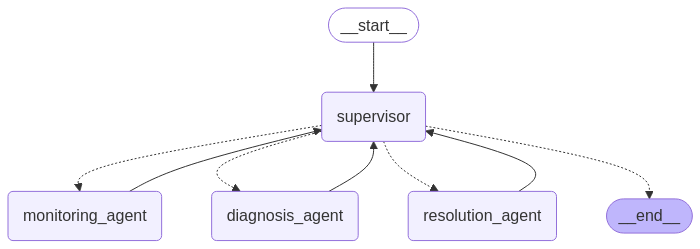

In [25]:
from IPython.display import display, Image

display(Image(aws_monitoring_workflow.get_graph().draw_mermaid_png()))



### Invoke the graph

In [28]:
txt = """
I want to check my EC2 instances. Check for if any of the instances is in alarm state, why it is in alarm state, 
how to diagnose it, and resolve it.
"""

# Run the workflow
events = aws_monitoring_workflow.stream(
    {"messages": [{"role": "user", "content": txt}]}, 
    {"recursion_limit": 10}
)

# Log and save the events
logger.info(f"{Fore.MAGENTA}=== STARTING AWS MONITORING WORKFLOW ==={Style.RESET_ALL}")

with open("output.txt", "a") as file:
    from datetime import datetime
    
    if events is not None:
        for event in events:
            # Log the node being executed
            for node_name, node_output in event.items():
                logger.info(f"{Fore.CYAN}[NODE: {node_name}]{Style.RESET_ALL}")
                
                # Special handling for supervisor node
                if node_name == "supervisor":
                    workflow_state = node_output.get("workflow", {})
                    logger.info(f"{Fore.MAGENTA}Workflow State: {workflow_state}{Style.RESET_ALL}")
                else:
                    # For agent nodes, pretty print the messages
                    pretty_print_messages(node_output)
                
                # Save to file
                file.write(f"{datetime.now()} - {node_name}: {str(node_output)}\n")
    else:
        error_msg = "Workflow events stream is None"
        logger.error(error_msg)
        file.write(f"{datetime.now()} - ERROR: {error_msg}\n")

logger.info(f"{Fore.MAGENTA}=== WORKFLOW COMPLETE ==={Style.RESET_ALL}")

=== STARTING AWS MONITORING WORKFLOW ===


Supervisor routing to: monitoring_agent
Workflow state: {'current_step': 'monitoring_agent', 'monitoring_complete': False, 'diagnosis_complete': False, 'resolution_complete': False}


[NODE: supervisor]
Workflow State: {'current_step': 'monitoring_agent', 'monitoring_complete': False, 'diagnosis_complete': False, 'resolution_complete': False}
/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_76724/1484446638.py:58: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  StartTime=datetime.utcnow() - timedelta(minutes=10),
/var/folders/jy/g9mb5j5n6c11fgdj788p5rww0000gr/T/ipykernel_76724/1484446638.py:59: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  EndTime=datetime.utcnow()
[NODE: monitoring_agent]
[HUMAN] 
I want to check my EC2 instances. Check for if any of the instances is in alarm state, why it is in alarm state, 
how to diagnose it, and resolve it.


Supervisor routing to: diagnosis_agent
Workflow state: {'current_step': 'diagnosis_agent', 'monitoring_complete': True, 'diagnosis_complete': False, 'resolution_complete': False}


[NODE: supervisor]
Workflow State: {'current_step': 'diagnosis_agent', 'monitoring_complete': True, 'diagnosis_complete': False, 'resolution_complete': False}
[NODE: diagnosis_agent]
[HUMAN] 
I want to check my EC2 instances. Check for if any of the instances is in alarm state, why it is in alarm state, 
how to diagnose it, and resolve it.

[AI] {'messages': [HumanMessage(content='\nI want to check my EC2 instances. Check for if any of the instances is in alarm state, why it is in alarm state, \nhow to diagnose it, and resolve it.\n', additional_kwargs={}, response_metadata={}, id='9af22668-d61d-42db-8828-d15ad1e5d27a'), AIMessage(content=[{'type': 'text', 'text': "<thinking> To address the user's request, I need to check the status of EC2 instances, specifically if any are in an alarm state. I will use the provided tool to fetch alarms and retrieve key utilization metrics for affected EC2 instances. This will help identify any performance issues, outages, or anomalies. </thinking>\n\n

...

[NODE: resolution_agent]
[HUMAN] 
I want to check my EC2 instances. Check for if any of the instances is in alarm state, why it is in alarm state, 
how to diagnose it, and resolve it.

[AI] {'messages': [HumanMessage(content='\nI want to check my EC2 instances. Check for if any of the instances is in alarm state, why it is in alarm state, \nhow to diagnose it, and resolve it.\n', additional_kwargs={}, response_metadata={}, id='9af22668-d61d-42db-8828-d15ad1e5d27a'), AIMessage(content=[{'type': 'text', 'text': "<thinking> To address the user's request, I need to check the status of EC2 instances, specifically if any are in an alarm state. I will use the provided tool to fetch alarms and retrieve key utilization metrics for affected EC2 instances. This will help identify any performance issues, outages, or anomalies. </thinking>\n\n"}, {'type': 'tool_use', 'name': 'fetch_ec2_metrics_for_alarm_instances', 'input': {}, 'id': 'tooluse_lXYYp51zS52S8t0PtfsEuA'}], additional_kwargs={}, respons

Supervisor routing to: resolution_agent
Workflow state: {'current_step': 'resolution_agent', 'monitoring_complete': True, 'diagnosis_complete': True, 'resolution_complete': False}


[NODE: supervisor]
Workflow State: {'current_step': 'resolution_agent', 'monitoring_complete': True, 'diagnosis_complete': True, 'resolution_complete': False}
[NODE: resolution_agent]
[HUMAN] 
I want to check my EC2 instances. Check for if any of the instances is in alarm state, why it is in alarm state, 
how to diagnose it, and resolve it.

[AI] {'messages': [HumanMessage(content='\nI want to check my EC2 instances. Check for if any of the instances is in alarm state, why it is in alarm state, \nhow to diagnose it, and resolve it.\n', additional_kwargs={}, response_metadata={}, id='9af22668-d61d-42db-8828-d15ad1e5d27a'), AIMessage(content=[{'type': 'text', 'text': "<thinking> To address the user's request, I need to check the status of EC2 instances, specifically if any are in an alarm state. I will use the provided tool to fetch alarms and retrieve key utilization metrics for affected EC2 instances. This will help identify any performance issues, outages, or anomalies. </thinking>\n\

Supervisor routing to: END
Workflow state: {'current_step': 'END', 'monitoring_complete': True, 'diagnosis_complete': True, 'resolution_complete': True}


[NODE: supervisor]
Workflow State: {'current_step': 'END', 'monitoring_complete': True, 'diagnosis_complete': True, 'resolution_complete': True}
=== WORKFLOW COMPLETE ===
